# Demo 2: Controlled Pendulum
## Demo 2.8: Update SysSimX

- **Connections**

- **System**

- **Resolving Computational Causality**

- **System Graph Creation**

In [1]:
import sys
import numpy as np
from path import Path

repo_root = Path.getcwd().parent.parent
sys.path.insert(0, str(repo_root))

**Generate FMUComponents**

In [2]:
from SysSimX.utilities.update_fmus import get_fmu_paths
from SysSimX.core.fmu_comp import FMUComponent

demo_dir_path = Path(repo_root / 'demos' / 'ControlledPendulum')
package_path = Path(demo_dir_path / 'ControlledPendulum')
fmu_output_dir = Path(demo_dir_path / 'FMUs')
fmu_paths = get_fmu_paths(package_path, fmu_output_dir, force_rebuild=False)

ref          = FMUComponent(name='ref', fmu_path=fmu_paths['Reference'], group='Input')
sensor_ref   = FMUComponent(name='sensor_ref', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
sensor_state = FMUComponent(name='sensor_state', fmu_path=fmu_paths['AngleEncoder'], group='Sensors')
pid          = FMUComponent(name='pid', fmu_path=fmu_paths['PID_Continuous'], group='Control')
drive        = FMUComponent(name='drive', fmu_path=fmu_paths['Drive'], group='Actuator')
pendulum     = FMUComponent(name='pendulum', fmu_path=fmu_paths['Pendulum'], group='Plant')

All FMUs for package 'ControlledPendulum' already exist. Skipping generation.


**Simulation Parameters**

In [3]:
# Simulation parameters
t0, tf, h = 0, 10, 0.01

**Define Connections**

In [8]:
from SysSimX.system.connection import Connection

c1 = Connection(src_comp=ref.name, src_port=ref.output_specs['q_ref'].name,
                dst_comp=sensor_ref.name, dst_port=sensor_ref.input_specs['q'].name)

c2 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['q_state'].name,
                dst_comp=sensor_state.name, dst_port=sensor_state.input_specs['q'].name,
                delay=1)

c3 = Connection(src_comp=sensor_ref.name, src_port=sensor_ref.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['ref'].name)

c4 = Connection(src_comp=sensor_state.name, src_port=sensor_state.output_specs['U_q'].name,
                dst_comp=pid.name, dst_port=pid.input_specs['y'].name)

c5 = Connection(src_comp=pid.name, src_port=pid.output_specs['u'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['u_control'].name)

c6 = Connection(src_comp=drive.name, src_port=drive.output_specs['torque'].name,
                dst_comp=pendulum.name, dst_port=pendulum.input_specs['torque'].name)

c7 = Connection(src_comp=pendulum.name, src_port=pendulum.output_specs['omega_state'].name,
                dst_comp=drive.name, dst_port=drive.input_specs['omega'].name,
                delay=1)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [ref, sensor_ref, sensor_state, pid, drive, pendulum]

**Define System**

In [9]:
from SysSimX.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

In [10]:
for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
try:
    system.add_connection(c1)
except ValueError as e:
    print(f"Error: {e}")
system.compute_execution_order()

Error: Duplicate connection: ref.q_ref -> sensor_ref.q with delay 0


**Create System Graph**

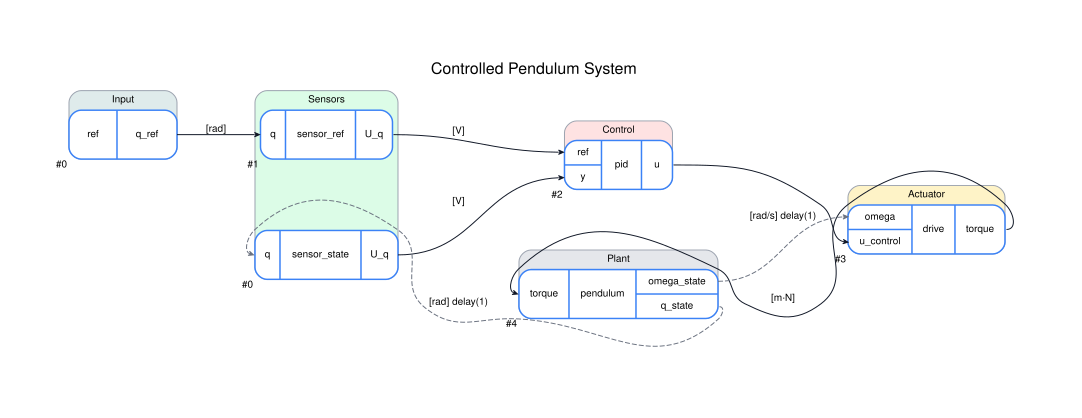

In [11]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [12]:
system.initialize(t0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [13]:
system.run(t0, tf, h)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [14]:
res_ref = system.components['ref'].outputs['q_ref'].history
res_state = system.components['pendulum'].outputs['q_state'].history

t_vals = []
q_ref_vals = []

for e in res_ref:
    t = e[0]
    q_ref = e[1]
    t_vals.append(t)
    q_ref_vals.append(q_ref)

q_state_vals = []
for e in res_state:
    q_state = e[1]
    q_state_vals.append(q_state)

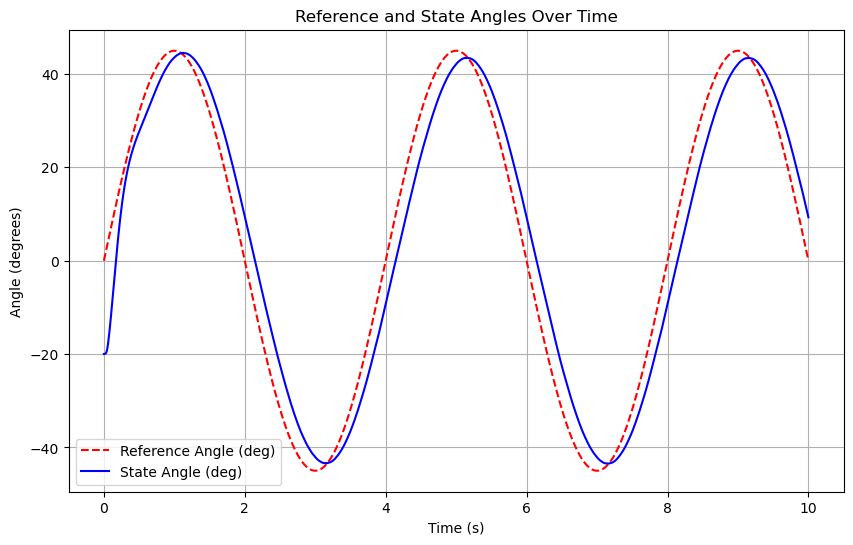

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_ref_vals), label='Reference Angle (deg)', color='red', linestyle='--')
plt.plot(t_vals, np.rad2deg(q_state_vals), label='State Angle (deg)', color='blue')
plt.title('Reference and State Angles Over Time')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.grid(True)
plt.legend()
plt.show()

------------------------